### Referências

- **Artigo:** https://link.springer.com/article/10.1186/s12917-022-03363-9
- **Datasets:** https://figshare.com/articles/datasetEPIDEMIOLOGY_OF_CANINE_MAMMARY_TUMOURS_ON_THE_CANARY_ARCHIPELAGO_IN_SPAIN_/19688721?file=34971837

## Análise Epidemiológica dos Tumores

In [1]:
import pandas as pd
import numpy as np
from scipy import stats

df_tumores = pd.read_csv('../data/all_tumoursFD.csv', encoding='latin1')
mammary_tumours = df_tumores[df_tumores['Location'] == 'Mammary gland'].copy()


# =====================================================================
# TABELA 1: Proporção de laudos de acordo com o número de nódulos (CMT)
# =====================================================================
print("\n--- TABELA 1: Número de nódulos por laudo ---")
contagem_nodulos = mammary_tumours.groupby('ReportRef').size()
contagem_nodulos = contagem_nodulos.apply(lambda x: ">=5" if x >= 5 else str(x))

tabela_1 = contagem_nodulos.value_counts(normalize=True).sort_index() * 100
print(tabela_1.round(2).astype(str) + '%')



--- TABELA 1: Número de nódulos por laudo ---
1      74.31%
2      16.55%
3       5.67%
4       2.19%
>=5     1.28%
Name: proportion, dtype: object


In [2]:
# =====================================================================
# TABELAS 2 e 3: Proporção dos tipos de tumores Malignos e Benignos
# O artigo calcula o Intervalo de Confiança (IC 95%) usando um Teste Binomial
# =====================================================================
print("\n--- TABELAS 2 e 3: Tipos Histológicos (com IC 95%) ---")
for status in ['Malignant', 'Benign']:
    print(f"\n>>> Tumores {status}s:")
    subset = mammary_tumours[mammary_tumours['Benign_Malignant'] == status]
    total = len(subset)
    tipos = subset['Primary_tumour'].value_counts()
    
    for tipo, contagem in tipos.items():
        pct = (contagem / total) * 100
        resultado_binom = stats.binomtest(contagem, total)
        ic_inferior = resultado_binom.proportion_ci(confidence_level=0.95).low * 100
        ic_superior = resultado_binom.proportion_ci(confidence_level=0.95).high * 100
        
        print(f"{tipo}: {pct:.2f}% (IC 95%: {ic_inferior:.2f}% a {ic_superior:.2f}%)")


--- TABELAS 2 e 3: Tipos Histológicos (com IC 95%) ---

>>> Tumores Malignants:
Complex carcinoma: 40.96% (IC 95%: 39.77% a 42.16%)
Tubulopapillary carcinoma: 26.82% (IC 95%: 25.75% a 27.90%)
Carcinoma arising in mixed benign tumour: 18.46% (IC 95%: 17.53% a 19.42%)
Solid carcinoma: 6.17% (IC 95%: 5.60% a 6.78%)
Carcinosarcoma: 2.04% (IC 95%: 1.71% a 2.41%)


Anaplastic carcinoma: 1.08% (IC 95%: 0.84% a 1.36%)
Squamous cell carcinoma: 0.93% (IC 95%: 0.71% a 1.19%)
Carcinoma NOS: 0.76% (IC 95%: 0.56% a 1.00%)
In situ carcinoma: 0.52% (IC 95%: 0.36% a 0.72%)
Osteosarcoma: 0.47% (IC 95%: 0.32% a 0.67%)
Fibrosarcoma: 0.32% (IC 95%: 0.20% a 0.49%)
Ductal carcinoma: 0.32% (IC 95%: 0.20% a 0.49%)
Inflammatory carcinoma: 0.30% (IC 95%: 0.19% a 0.47%)
Haemangiosarcoma: 0.29% (IC 95%: 0.17% a 0.45%)
Malignant myoepithelioma: 0.15% (IC 95%: 0.07% a 0.28%)
Sarcoma NOS: 0.11% (IC 95%: 0.04% a 0.22%)
Lipid-rich (secretory) carcinoma: 0.11% (IC 95%: 0.04% a 0.22%)
Carcinoma and malignant myoepithelioma: 0.06% (IC 95%: 0.02% a 0.16%)
Adenosquamous carcinoma: 0.03% (IC 95%: 0.00% a 0.11%)
Micropapillary invasive carcinoma: 0.03% (IC 95%: 0.00% a 0.11%)
Intraductal papillary carcinoma: 0.03% (IC 95%: 0.00% a 0.11%)
Cribriform carcinoma: 0.03% (IC 95%: 0.00% a 0.11%)
Spindle cell carcinoma: 0.02% (IC 95%: 0.00% a 0.08%)
Osteochondrosarcoma: 0.02% (IC 95%: 0.0

In [3]:
# =====================================================================
# TABELA 4: Número de Casos e Controles por Ano de Nascimento
# =====================================================================

df_tumores = pd.read_csv('../data/all_tumoursFD.csv', encoding='latin1')
df_animais = pd.read_csv('../data/zoocan.csv', encoding='latin1')

df_animais = df_animais.rename(columns={'Isle': 'Island'})
controls = df_animais[(df_animais['Year_of_birth'] >= 2003) & (df_animais['Year_of_birth'] <= 2013)].copy()
controls = controls[['Breed', 'Year_of_birth', 'Island']]
controls['id'] = ['CTRL-' + str(i+1) for i in range(len(controls))]
controls['group'] = 'Control'

mammary_tumours = df_tumores[df_tumores['Location'] == 'Mammary gland'].copy()
cases = mammary_tumours[(mammary_tumours['Year_of_birth'] >= 2003) & (mammary_tumours['Year_of_birth'] <= 2013)].copy()
cases['id'] = cases['ReportRef'].astype(str)
cases = cases[['id', 'Breed', 'Year_of_birth', 'Island']].drop_duplicates()
cases['group'] = 'Case'

study = pd.concat([controls, cases], ignore_index=True)
study['Breed'] = study['Breed'].replace('No_info', np.nan)

print("\n--- TABELA 4: Distribuição da População do Estudo ---")
tabela_4 = pd.crosstab(
    study['Year_of_birth'], 
    study['group'], 
    margins=True, 
    margins_name="Total"
)
print(tabela_4)


--- TABELA 4: Distribuição da População do Estudo ---
group          Case  Control  Total
Year_of_birth                      
2003.0          242      271    513
2004.0          241      354    595
2005.0          212      601    813
2006.0          258      945   1203
2007.0          272     1470   1742
2008.0          256     2274   2530
2009.0          202     4182   4384
2010.0          172    12312  12484
2011.0          107    19064  19171
2012.0           91    18667  18758
2013.0           30    18960  18990
Total          2083    79100  81183


In [4]:
# =====================================================================
# TABELA 5: Distribuição de idade por tipo de tumor e status de castração
# =====================================================================

print("\n--- TABELA 5: Idade média por Tipo Histológico e Castração ---")
tabela_5 = mammary_tumours.groupby(['Neuter_status', 'Etiqueta3_morfologia'])['Age'].agg(['count', 'mean', 'std']).dropna()
tabela_5 = tabela_5.round({'mean': 2, 'std': 2}) 
tabela_5 = tabela_5.rename(columns={'count': 'Casos', 'mean': 'Idade Média', 'std': 'Desvio Padrão'})
print(tabela_5)


--- TABELA 5: Idade média por Tipo Histológico e Castração ---
                                            Casos  Idade Média  Desvio Padrão
Neuter_status Etiqueta3_morfologia                                           
Entire        Benign tumours                  493         8.95           2.60
              Malignant epithelial tumours   4547         9.57           2.47
              Sarcomas                         50        10.40           3.14
Neutered      Benign tumours                  198         9.73           2.40
              Malignant epithelial tumours   1324        10.24           2.54
              Sarcomas                         20        10.35           2.50


In [5]:
# =====================================================================
# TABELA 6: Diferença de idades em que os tumores são diagnosticados
# Compara a idade de cadelas Inteiras vs Castradas usando Teste T
# =====================================================================

print("\n--- TABELA 6: Teste Estatístico de Idade (Inteiras vs Castradas) ---")
tipos_principais = mammary_tumours['Etiqueta3_morfologia'].dropna().unique()

for tipo in tipos_principais:
    df_tipo = mammary_tumours[mammary_tumours['Etiqueta3_morfologia'] == tipo].dropna(subset=['Age', 'Neuter_status'])
    
    inteiras = df_tipo[df_tipo['Neuter_status'] == 'Entire']['Age']
    castradas = df_tipo[df_tipo['Neuter_status'] == 'Neutered']['Age']
    
    if len(inteiras) > 1 and len(castradas) > 1:
        # Teste T para amostras independentes (Welch's t-test)
        t_stat, p_val = stats.ttest_ind(inteiras, castradas, equal_var=False)
        diff_idade = inteiras.mean() - castradas.mean()
        print(f"Tipo: {tipo} | Diferença: {diff_idade:.2f} anos | P-value = {p_val:.4f}")


--- TABELA 6: Teste Estatístico de Idade (Inteiras vs Castradas) ---
Tipo: Malignant epithelial tumours | Diferença: -0.67 anos | P-value = 0.0000
Tipo: Benign tumours | Diferença: -0.78 anos | P-value = 0.0002
Tipo: Sarcomas | Diferença: 0.05 anos | P-value = 0.9445


## Estudo de Caso-Controle / Risco por Raça

### Modelo

In [9]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf


df_tumores = pd.read_csv('../data/all_tumoursFD.csv', encoding='latin1')
df_animais = pd.read_csv('../data/zoocan.csv', encoding='latin1')

# Preparando os Controles (Cães Saudáveis)
df_animais = df_animais.rename(columns={'Isle': 'Island'})
controls = df_animais[
    (df_animais['Year_of_birth'] >= 2003) & 
    (df_animais['Year_of_birth'] <= 2013) &
    (df_animais['Gender'] == 'Female')
].copy()
controls = controls[['Breed', 'Year_of_birth', 'Island']]
controls['group'] = 0  # 0 = Saudável

# Preparando os Casos (Cães com Tumores Mamários Malignos)
mammary_tumours = df_tumores[
    (df_tumores['Location'] == 'Mammary gland') & 
    (df_tumores['Etiqueta2_morfologia'] == 'Malignant epithelial tumours')
].copy()

cases = mammary_tumours[(mammary_tumours['Year_of_birth'] >= 2003) & (mammary_tumours['Year_of_birth'] <= 2013)].copy()
cases['id'] = cases['ReportRef'].astype(str)
cases = cases[['id', 'Breed', 'Year_of_birth', 'Island']].drop_duplicates()
cases['group'] = 1  # 1 = Câncer

# Concatenando os dois grupos
study = pd.concat([controls[['Breed', 'Island', 'group']], cases[['Breed', 'Island', 'group']]], ignore_index=True)

# Limpeza: Removendo cães sem raça ou ilha identificadas
study['Breed'] = study['Breed'].replace('No_info', np.nan)
study = study.dropna(subset=['Breed', 'Island']) 

# Tabela cruzada para contar quantos cães saudáveis (0) e doentes (1) cada raça tem
tabela_racas = pd.crosstab(study['Breed'], study['group'])

# Filtra pegando apenas o nome das raças que possuem >= 5 na coluna 1 (Casos)
racas_validas = tabela_racas[tabela_racas[1] >= 5].index.tolist()

# Criando o DataFrame final
study_filtrado = study[study['Breed'].isin(racas_validas)].copy()

study_filtrado.to_csv('../data/study_filtered.csv', index=False)

# Fórmula usando as mesmas referências do R (Gran Canaria e Crossbreed)
formula = "group ~ C(Island, Treatment(reference='Gran Canaria')) + C(Breed, Treatment(reference='Crossbreed'))"

# Ajustando o modelo
modelo = smf.logit(formula, data=study_filtrado).fit(disp=0)

print("\nResumo do Modelo Estatístico:")
print(modelo.summary())


Resumo do Modelo Estatístico:
                           Logit Regression Results                           
Dep. Variable:                  group   No. Observations:                76117
Model:                          Logit   Df Residuals:                    76074
Method:                           MLE   Df Model:                           42
Date:                Mon, 04 May 2026   Pseudo R-squ.:                  0.1215
Time:                        08:54:56   Log-Likelihood:                -7532.8
converged:                       True   LL-Null:                       -8574.4
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                    

**OR (Odds Ratio): É o risco!**

- Um OR = 1.0 seria o risco de um cachorro SRD (Crossbreed).
- Se a raça tiver um OR = 3.5, significa que ela tem 3,5 vezes mais chance de ter um tumor de mama do que um SRD. 

- Se tiver um OR = 0.2, significa que tem 80% a menos de chance do que um SRD (Fator de proteção)

**P-value:**
Se o valor for menor que 0.05, o risco medido é estatisticamente válido/verdadeiro. Se for maior que 0.05, significa que não temos certeza estatística se a raça realmente tem esse risco ou se foi apenas coincidência na amostra.

**CI (Intervalo de Confiança):**
É a margem de erro do OR.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# TABELA 7: OR, CI, P-value e Frequências (Equivalente ao script R)
# ==============================================================================

# 1. Extraindo os valores matemáticos puros do modelo (É mais seguro que ler o summary)
resultados = pd.DataFrame({
    'Coeficiente': modelo.params,
    'CI_Inferior': modelo.conf_int()[0],
    'CI_Superior': modelo.conf_int()[1],
    
    'P_value': modelo.pvalues
})

# Calculando os Odds Ratios e ICs (Exponencial do coeficiente)
resultados['OR'] = np.exp(resultados['Coeficiente'])
resultados['CI_Inferior'] = np.exp(resultados['CI_Inferior'])
resultados['CI_Superior'] = np.exp(resultados['CI_Superior'])

# 2. Limpando os nomes das variáveis geradas pelo Patsy/Statsmodels
# (Ex: "C(Breed, Treatment(reference='Crossbreed'))[T.Poodle]" vira "Breed", "Poodle")
def extrair_nomes(nome):
    if 'Island' in nome:
        return 'Island', nome.split('[T.')[-1].replace(']', '')
    elif 'Breed' in nome:
        return 'Breed', nome.split('[T.')[-1].replace(']', '')
    else:
        return 'Intercept', 'Intercept'

resultados['Effect'], resultados['Value'] = zip(*resultados.index.map(extrair_nomes))
resultados = resultados[resultados['Effect'] != 'Intercept'].copy() # Removemos o Intercepto

# Formatando as colunas visuais
resultados['CI'] = resultados.apply(lambda row: f"[{row['CI_Inferior']:.2f}, {row['CI_Superior']:.2f}]", axis=1)
resultados['P_value'] = resultados['P_value'].apply(lambda p: "<0.0001" if p < 0.0001 else f"{p:.4f}")
resultados['OR'] = resultados['OR'].round(2)

# 3. Calculando Casos e Controles (Equivalente ao tabyl + adorn_percentages do R)
def contagens_e_percentuais(df, coluna):
    ct = pd.crosstab(df[coluna], df['group'])
    ct.columns = ['Control', 'Case']
    
    # Percentual por coluna (Quantos % dos Controles são Poodles?)
    ct_pct = ct.div(ct.sum(axis=0), axis=1) * 100 
    
    df_contagem = pd.DataFrame({
        'Effect': coluna,
        'Value': ct.index,
        'Controls No. (%)': ct.apply(lambda r: f"{r['Control']} ({ct_pct.loc[r.name, 'Control']:.1f}%)", axis=1),
        'Cases No. (%)': ct.apply(lambda r: f"{r['Case']} ({ct_pct.loc[r.name, 'Case']:.1f}%)", axis=1)
    })
    return df_contagem

freq_ilha = contagens_e_percentuais(study_filtrado, 'Island')
freq_raca = contagens_e_percentuais(study_filtrado, 'Breed')
frequencias = pd.concat([freq_ilha, freq_raca], ignore_index=True)

# 4. Juntando as Frequências com os Odds Ratios
tabela_7 = pd.merge(frequencias, resultados[['Value', 'OR', 'CI', 'P_value']], on='Value', how='left')

# 5. Adicionando as Referências com OR = 1 (O modelo omite elas, precisamos colocar na mão)
tabela_7.loc[tabela_7['Value'] == 'Crossbreed', ['OR', 'CI', 'P_value']] = [1.0, '-', '-']
tabela_7.loc[tabela_7['Value'] == 'Gran Canaria', ['OR', 'CI', 'P_value']] = [1.0, '-', '-']

# 6. Ordenando por Risco (OR) descendente dentro de cada Grupo (Island e Breed)
tabela_7 = tabela_7.sort_values(by=['Effect', 'OR'], ascending=[False, False])

# Reorganizando a ordem das colunas para ficar igual ao R
tabela_7 = tabela_7[['Effect', 'Value', 'Controls No. (%)', 'Cases No. (%)', 'OR', 'CI', 'P_value']]

print("\n=======================================================")
print("TABELA 7")
print("=======================================================")
print(tabela_7.to_string(index=False))


TABELA 7
Effect                          Value Controls No. (%) Cases No. (%)   OR            CI P_value
Island                   Gran Canaria    25562 (34.4%)  1249 (68.8%) 1.00             -       -
Island                  Fuerteventura      5754 (7.7%)    172 (9.5%) 0.64  [0.54, 0.75] <0.0001
Island                      La Gomera       706 (1.0%)      9 (0.5%) 0.29  [0.15, 0.56]  0.0002
Island                       Tenerife    31306 (42.1%)   322 (17.7%) 0.21  [0.18, 0.24] <0.0001
Island                      Lanzarote      5694 (7.7%)     55 (3.0%) 0.19  [0.15, 0.25] <0.0001
Island                      El Hierro       612 (0.8%)      3 (0.2%) 0.17  [0.05, 0.53]  0.0024
Island                       La Palma      4668 (6.3%)      5 (0.3%) 0.03  [0.01, 0.08] <0.0001
 Breed                        Samoyed        38 (0.1%)      5 (0.3%) 5.99 [2.27, 15.79]  0.0003
 Breed                      Schnauzer        53 (0.1%)      9 (0.5%) 5.67 [2.73, 11.79] <0.0001
 Breed                        

### Avaliação Comparativa

In [11]:
from sklearn.metrics import roc_auc_score, brier_score_loss


probabilidades_autor = modelo.predict(study_filtrado)

target = study_filtrado['group']

auc_autor = roc_auc_score(target, probabilidades_autor)
brier_autor = brier_score_loss(target, probabilidades_autor)

print("--- Desempenho do Modelo do Autor (Baseline) ---")
print(f"AUC-ROC: {auc_autor:.3f} (Quão bem ele separa doentes de saudáveis)")
print(f"Brier Score: {brier_autor:.3f} (Quão bem calibrada é a porcentagem. Mais baixo é melhor)")

--- Desempenho do Modelo do Autor (Baseline) ---
AUC-ROC: 0.788 (Quão bem ele separa doentes de saudáveis)
Brier Score: 0.022 (Quão bem calibrada é a porcentagem. Mais baixo é melhor)


## Análises Temporais e Correlações


--- TESTE DE CORRELAÇÃO (Castração x Tumores de Mama) ---
Correlação de Pearson (R): -0.84
P-value: 0.0000


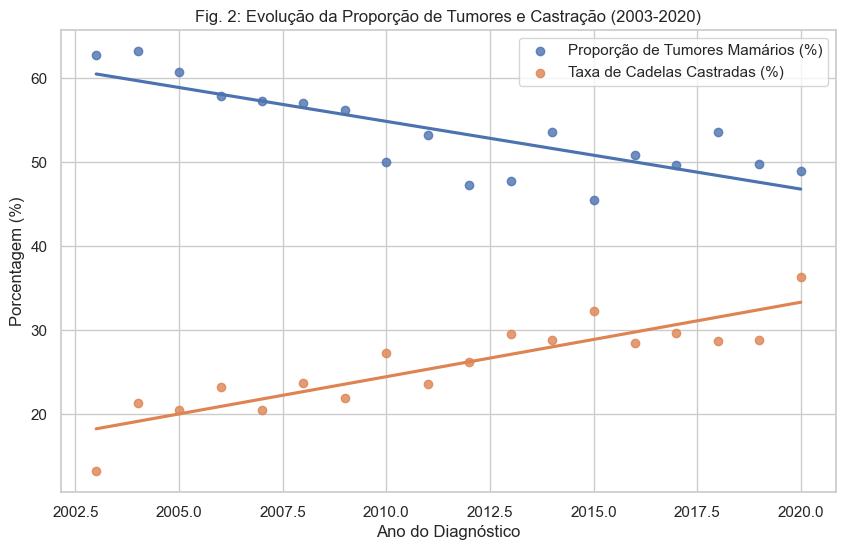

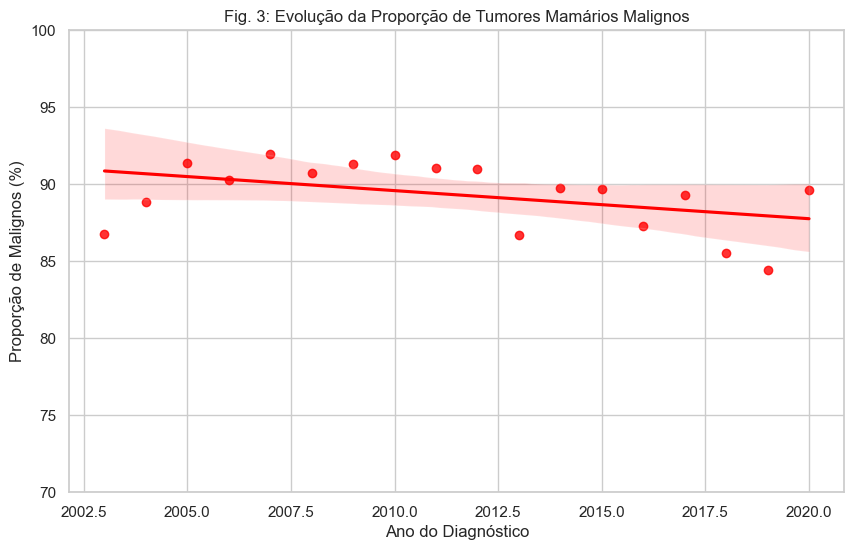

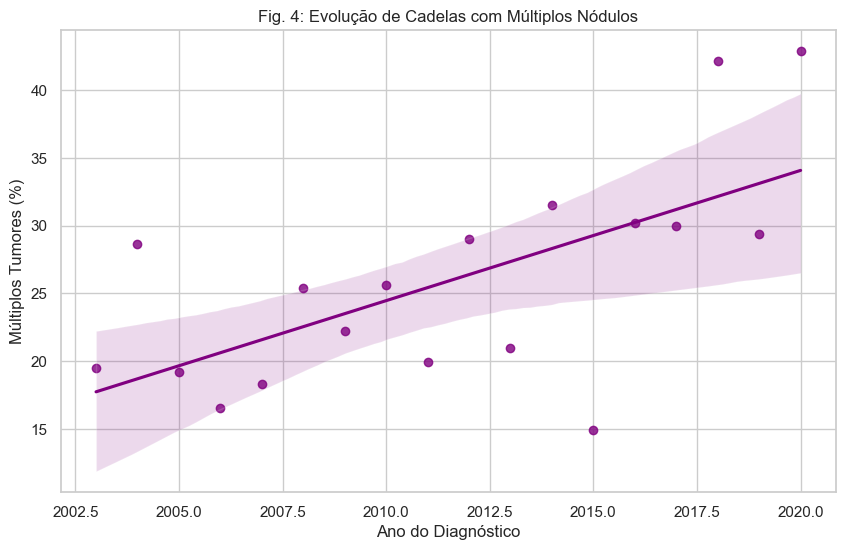

In [12]:
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df_tumores = pd.read_csv('../data/all_tumoursFD.csv', encoding='latin1')

df_tumores['Is_CMT'] = df_tumores['Location'] == 'Mammary gland'
casos_por_ano = df_tumores.groupby('ResultDate')['Is_CMT'].agg(['sum', 'count'])
casos_por_ano['Pct_CMT'] = casos_por_ano['sum'] / casos_por_ano['count']

pacientes_unicos = df_tumores[['ReportRef', 'ResultDate', 'Neuter_status']].drop_duplicates()
pacientes_unicos['Is_Neutered'] = pacientes_unicos['Neuter_status'] == 'Neutered'
castracao_por_ano = pacientes_unicos.groupby('ResultDate')['Is_Neutered'].mean()

dados_anuais = pd.DataFrame({
    'Pct_CMT': casos_por_ano['Pct_CMT'],
    'Pct_Neutered': castracao_por_ano
}).dropna()


print("\n--- TESTE DE CORRELAÇÃO (Castração x Tumores de Mama) ---")
correlacao, p_valor = pearsonr(dados_anuais['Pct_Neutered'], dados_anuais['Pct_CMT'])
print(f"Correlação de Pearson (R): {correlacao:.2f}")
print(f"P-value: {p_valor:.4f}")


# =====================================================================
# 3. GERAÇÃO DOS GRÁFICOS (Figuras 2, 3 e 4 do Artigo)
# =====================================================================

# --- FIGURA 2: Evolução de CMT vs Castração ---
plt.figure(figsize=(10, 6))
sns.regplot(x=dados_anuais.index, y=dados_anuais['Pct_CMT'] * 100, label='Proporção de Tumores Mamários (%)', scatter=True, order=1, ci=None)
sns.regplot(x=dados_anuais.index, y=dados_anuais['Pct_Neutered'] * 100, label='Taxa de Cadelas Castradas (%)', scatter=True, order=1, ci=None)
plt.title('Fig. 2: Evolução da Proporção de Tumores e Castração (2003-2020)')
plt.xlabel('Ano do Diagnóstico')
plt.ylabel('Porcentagem (%)')
plt.legend()
plt.savefig('../figs/Figura_2_Evolucao_CMT_Castracao.png', dpi=300, bbox_inches='tight') 
plt.show()

# --- FIGURA 3: Proporção de Tumores Malignos por ano ---
mammary_tumours = df_tumores[df_tumores['Location'] == 'Mammary gland'].copy()
mammary_tumours['Is_Malignant'] = mammary_tumours['Benign_Malignant'] == 'Malignant'
malignos_por_ano = mammary_tumours.groupby('ResultDate')['Is_Malignant'].mean() * 100

plt.figure(figsize=(10, 6))
sns.regplot(x=malignos_por_ano.index, y=malignos_por_ano.values, scatter=True, color='red')
plt.title('Fig. 3: Evolução da Proporção de Tumores Mamários Malignos')
plt.xlabel('Ano do Diagnóstico')
plt.ylabel('Proporção de Malignos (%)')
plt.ylim(70, 100) #
plt.savefig('../figs/Figura_3_Evolucao_Tumores_Malignos.png', dpi=300, bbox_inches='tight')
plt.show()

# --- FIGURA 4: Proporção de Múltiplos Tumores por ano ---
contagem_multiplos = mammary_tumours.groupby(['ResultDate', 'ReportRef']).size().reset_index(name='n_tumores')
contagem_multiplos['Is_Multiple'] = contagem_multiplos['n_tumores'] > 1
multiplos_por_ano = contagem_multiplos.groupby('ResultDate')['Is_Multiple'].mean() * 100

plt.figure(figsize=(10, 6))
sns.regplot(x=multiplos_por_ano.index, y=multiplos_por_ano.values, scatter=True, color='purple')
plt.title('Fig. 4: Evolução de Cadelas com Múltiplos Nódulos')
plt.xlabel('Ano do Diagnóstico')
plt.ylabel('Múltiplos Tumores (%)')
plt.savefig('../figs/Figura_4_Evolucao_Tumores_Multiplos.png', dpi=300, bbox_inches='tight') 
plt.show()

## Plotagem

### Gráfico de Barras das Raças

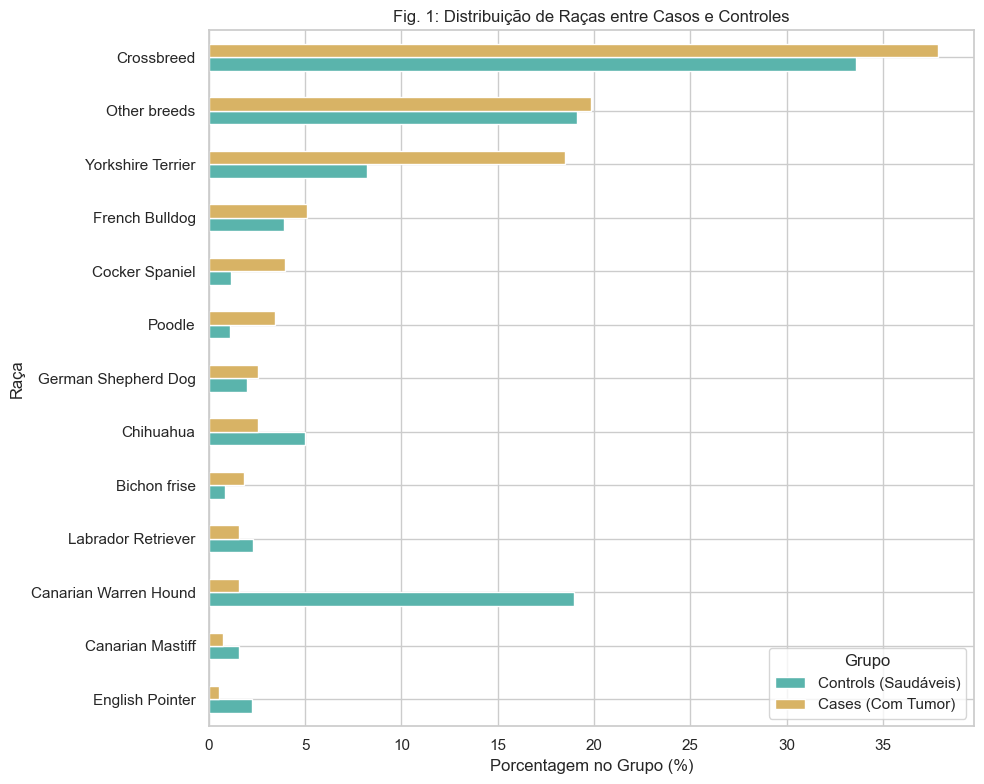

In [13]:
breed_counts = pd.crosstab(study['Breed'], study['group'], normalize='columns') * 100
breed_counts.columns = ['Controls (Saudáveis)', 'Cases (Com Tumor)']

breed_counts_filtered = breed_counts[(breed_counts['Cases (Com Tumor)'] >= 1.5) | 
                                     (breed_counts['Controls (Saudáveis)'] >= 1.5)].copy()

outras = breed_counts[(breed_counts['Cases (Com Tumor)'] < 1.5) & 
                      (breed_counts['Controls (Saudáveis)'] < 1.5)].sum()
outras.name = 'Other breeds'
breed_counts_filtered.loc['Other breeds'] = outras

breed_counts_filtered = breed_counts_filtered.sort_values(by='Cases (Com Tumor)', ascending=True)

ax = breed_counts_filtered.plot(kind='barh', figsize=(10, 8), color=['#5ab4ac', '#d8b365'])
plt.title('Fig. 1: Distribuição de Raças entre Casos e Controles')
plt.xlabel('Porcentagem no Grupo (%)')
plt.ylabel('Raça')
plt.legend(title='Grupo')
plt.tight_layout()
plt.savefig('../figs/Figura_1_Distribuicao_Racas.png', dpi=300, bbox_inches='tight')
plt.show()

### Gráfico Forest Plot de Risco

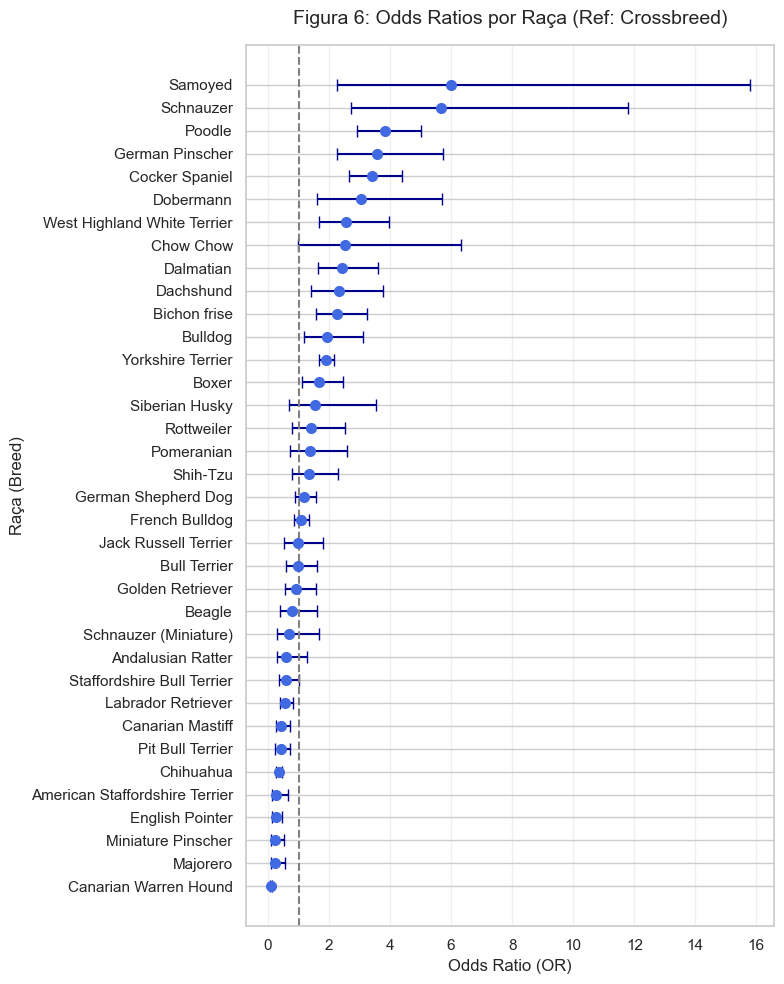

In [17]:
# ==============================================================================
# FIGURA 6: Forest Plot (Gráfico de Risco Relativo)
# ==============================================================================

# Filtramos apenas as raças e retiramos a referência (Crossbreed) para o gráfico
df_plot = resultados[resultados['Effect'] == 'Breed'].copy()

# Ordenamos crescente para que a barra com maior risco fique no topo do gráfico
df_plot = df_plot.sort_values(by='OR', ascending=True)

# Margens de erro para as linhas do gráfico (Diferença entre o OR e os limites)
erro_inferior = df_plot['OR'] - df_plot['CI_Inferior']
erro_superior = df_plot['CI_Superior'] - df_plot['OR']

plt.figure(figsize=(8, 10))

# Criando as marcações e os intervalos de confiança (O Forest Plot)
plt.errorbar(x=df_plot['OR'], y=df_plot['Value'], 
             xerr=[erro_inferior, erro_superior], 
             fmt='o', color='royalblue', ecolor='darkblue', 
             capsize=4, elinewidth=1.5, markersize=7)

# Desenhando a linha vertical do "Risco Neutro" (OR = 1)
plt.axvline(x=1, color='grey', linestyle='--')

# Configurações visuais do gráfico
plt.title('Figura 6: Odds Ratios por Raça (Ref: Crossbreed)', fontsize=14, pad=15)
plt.xlabel('Odds Ratio (OR)', fontsize=12)
plt.ylabel('Raça (Breed)', fontsize=12)
plt.grid(axis='x', alpha=0.3) # Linhas de grade sutis para facilitar a leitura

# Salva a imagem em alta resolução (equivalente ao tiff/dev.off() do R)
plt.tight_layout()
plt.savefig('../figs/Figura_6_Forest_Plot_Risco_Raca.png', dpi=300, bbox_inches='tight')
plt.show()

### Distribuição de idade de acordo com o tipo de tumor mamário

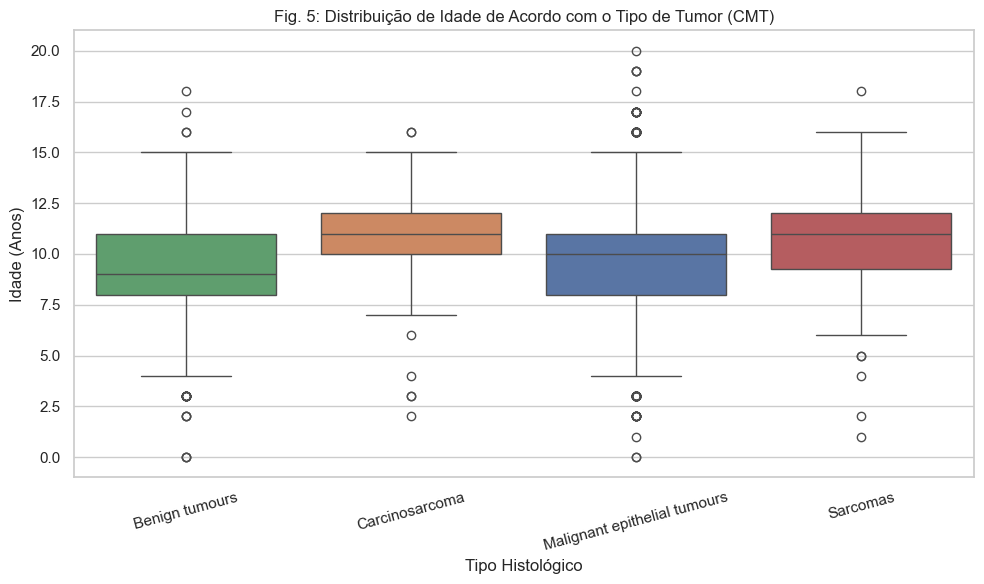

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df_tumores = pd.read_csv('../data/all_tumoursFD.csv', encoding='latin1')
mammary_tumours = df_tumores[df_tumores['Location'] == 'Mammary gland'].copy()
mammary_tumours = mammary_tumours.dropna(subset=['Age', 'Etiqueta3_morfologia'])

mammary_tumours['Tipo_Final'] = mammary_tumours['Etiqueta3_morfologia']

is_carcinosarcoma = mammary_tumours['Primary_tumour'] == 'Carcinosarcoma'
mammary_tumours.loc[is_carcinosarcoma, 'Tipo_Final'] = 'Carcinosarcoma'

ordem_oficial = [
    'Benign tumours', 
    'Carcinosarcoma', 
    'Malignant epithelial tumours', 
    'Sarcomas'
]


plt.figure(figsize=(10, 6))

sns.boxplot(
    x='Tipo_Final', 
    y='Age', 
    data=mammary_tumours, 
    order=ordem_oficial, 
    hue='Tipo_Final',
    legend=False,
)

plt.title('Fig. 5: Distribuição de Idade de Acordo com o Tipo de Tumor (CMT)')
plt.xlabel('Tipo Histológico')
plt.ylabel('Idade (Anos)')

plt.xticks(rotation=15)

plt.tight_layout()
plt.savefig('../figs/Figura_5_Idade_por_Tipo_Tumor.png', dpi=300, bbox_inches='tight')
plt.show()